In [1]:
"""
AI-ML Assignment 1
Medical Insurance Cost Prediction using Multiple Linear Regression
"""

'\nAI-ML Assignment 1\nMedical Insurance Cost Prediction using Multiple Linear Regression\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ---------------------------------------------------------
# Task 1: Data Understanding
# ---------------------------------------------------------
df = pd.read_csv("insurance.csv")

In [4]:
print("First 5 records:")
print(df.head())

First 5 records:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
numerical_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]
target_variable = "charges"

In [6]:
print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable:", target_variable)


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


In [7]:
# ---------------------------------------------------------
# Task 2: Data Preprocessing
# ---------------------------------------------------------
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
# encode categorical variables
df_encoded = df.copy()
df_encoded["sex"] = df_encoded["sex"].map({"male": 0, "female": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

In [9]:
X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# ---------------------------------------------------------
# Task 3: Model Development
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = model.predict(X_test)

In [13]:
print("\nModel coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


Model coefficients:
  age: 256.98
  sex: 18.59
  bmi: 337.09
  children: 425.28
  smoker: 23651.13
  region_northwest: -370.68
  region_southeast: -657.86
  region_southwest: -809.80
Intercept: -11949.81


In [14]:
# ---------------------------------------------------------
# Task 4: Model Evaluation
# ---------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print("\nEvaluation Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")


Evaluation Metrics:
MAE: 4181.19
MSE: 33596915.85
R2 Score: 0.7836


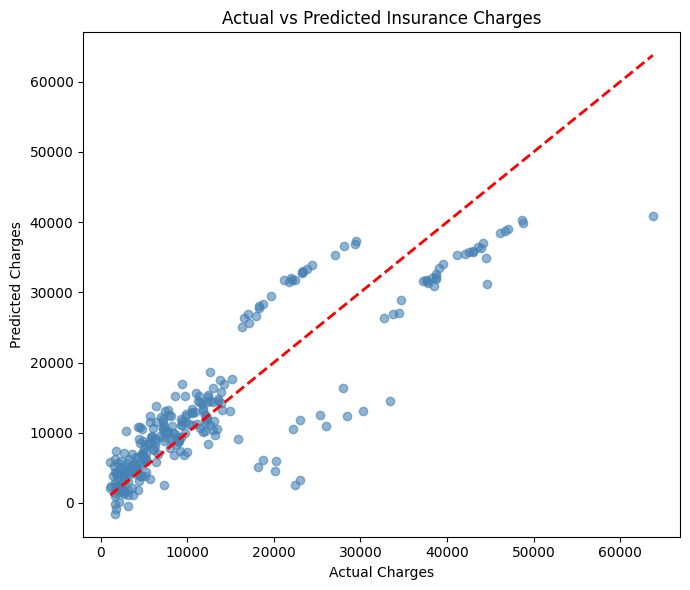

In [16]:
# actual vs predicted scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="steelblue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

In [17]:
"""
Observations:
1. Smoking status has the strongest positive effect on predicted charges.
2. Age and BMI both increase charges, but their effect is smaller than smoking.
3. The R2 score shows the model explains most, but not all, of the variance,
   suggesting a non-linear relationship not fully captured by linear regression.
"""

'\nObservations:\n1. Smoking status has the strongest positive effect on predicted charges.\n2. Age and BMI both increase charges, but their effect is smaller than smoking.\n3. The R2 score shows the model explains most, but not all, of the variance,\n   suggesting a non-linear relationship not fully captured by linear regression.\n'

In [18]:
# ---------------------------------------------------------
# Task 5: Conclusion
# ---------------------------------------------------------
conclusion = """
This project used Multiple Linear Regression to predict medical insurance
charges from age, sex, BMI, number of children, smoking status, and region.
Smoking status was found to be the strongest driver of charges, followed by
age and BMI, while sex and region had a much smaller influence. The model
achieved a reasonable fit on the test data, with the R2 score indicating that
a large portion of the variance in charges is explained by these features.
However, the relationship between charges and predictors such as BMI and
smoking is not purely linear in reality (e.g., charges rise sharply for
smokers with high BMI), which limits the model's accuracy for such cases.
A key limitation of Linear Regression here is its assumption of linear,
additive relationships between features and the target, which prevents it
from capturing interaction effects (such as smoker x BMI) without manual
feature engineering.
"""
print(conclusion)


This project used Multiple Linear Regression to predict medical insurance
charges from age, sex, BMI, number of children, smoking status, and region.
Smoking status was found to be the strongest driver of charges, followed by
age and BMI, while sex and region had a much smaller influence. The model
achieved a reasonable fit on the test data, with the R2 score indicating that
a large portion of the variance in charges is explained by these features.
However, the relationship between charges and predictors such as BMI and
smoking is not purely linear in reality (e.g., charges rise sharply for
smokers with high BMI), which limits the model's accuracy for such cases.
A key limitation of Linear Regression here is its assumption of linear,
additive relationships between features and the target, which prevents it
from capturing interaction effects (such as smoker x BMI) without manual
feature engineering.

